# CAPs Network Profile - preparing data for radar plots

For each CAP:
1. Maps the 1060-ROI atlas to 10 network labels (7 Yeo cortical networks + cerebellum, thalamus, subcortical).
2. Computes the **mean activation** per network, again split by sign. And saves per-CAP CSVs

In [1]:
import nibabel as nib
import numpy as np
import os
from nilearn import plotting
import os
import numpy as np
import nibabel as nib
from nilearn.maskers import NiftiLabelsMasker
import warnings
import os
import numpy as np
import nibabel as nib
import pandas as pd
from dotenv import load_dotenv
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
load_dotenv()
base_dir = os.environ['BASE_DIR']
runs_str = "run-ON"

results_dir = os.environ['RESULTS_DIR']
radar_output_dir = os.path.join(results_dir, "main_figures", "02_radar_figs")

runs = [2]
k=7

# Define dictionaries for labels
sessions_dict = {1: "Unilateral tDCS", 2: "Bilateral tDCS", 3: "Sham Stimulation"}
runs_dict = {1: "Off condition", 2: "On condition"}

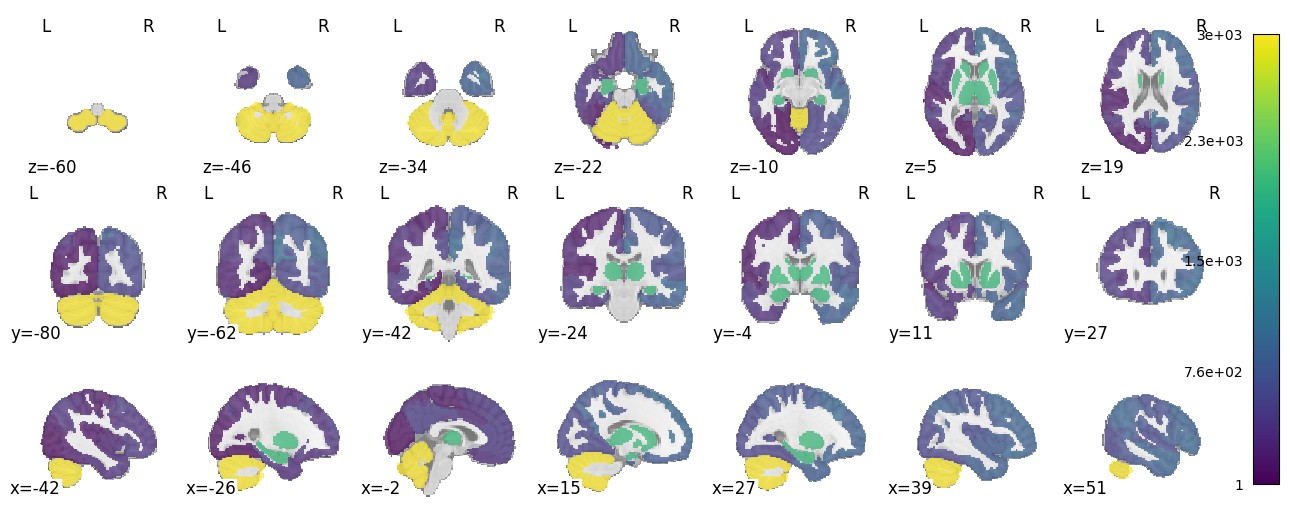

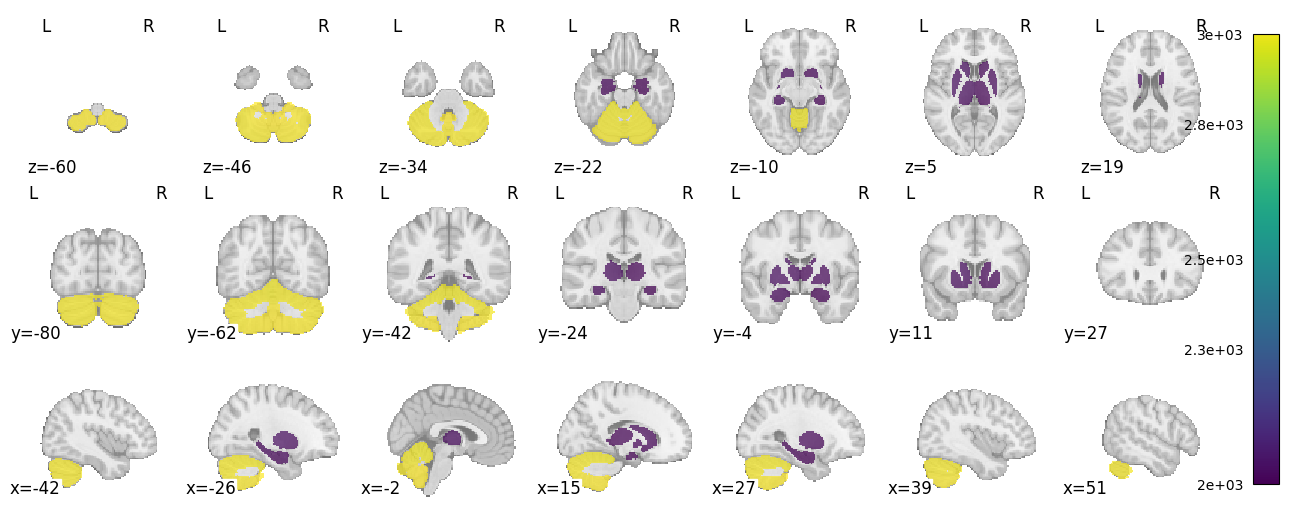

In [3]:
atlas_dir = os.environ['ATLAS_DIR']

atlas_filename = os.path.join(atlas_dir, "atlas_combined_tpl-MNI152NLin2009cAsym_res-02_T1w.nii.gz")

subcortical_atlas_filename = os.path.join(atlas_dir, "atlas_subcortical.nii.gz")

atlas_masker = NiftiLabelsMasker(labels_img=atlas_filename, mask_img=None, standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)

atlas_masker.fit()

atlas_labels = nib.load(atlas_masker.labels_img).get_fdata()

sub_cortical_labels = np.where(atlas_labels > 1000, atlas_labels, 0)

sub_cortical_mask = nib.Nifti1Image(sub_cortical_labels, affine=atlas_masker.labels_img_.affine)

nib.save(sub_cortical_mask, subcortical_atlas_filename)

sub_cortical_atlas = NiftiLabelsMasker(labels_img=subcortical_atlas_filename, mask_img=None,  standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)

plotting.plot_roi(atlas_filename, display_mode="mosaic", cmap="viridis", colorbar=True)

plotting.plot_roi(subcortical_atlas_filename, display_mode="mosaic", cmap="viridis", colorbar=True)

Read labels dataframe

In [4]:
data = []
atlas_labels_filename_txt = os.path.join(atlas_dir, "atlas_combined_labels.txt")
with open(atlas_labels_filename_txt, 'r') as f:
    next(f)  # Skip header line: "index  hemisphere  name"
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            index = parts[0]
            hemisphere = parts[1]
            name = ' '.join(parts[2:])
            data.append([index, hemisphere, name])

# Convert to DataFrame
atlas_labels_df = pd.DataFrame(data, columns=['index', 'hemisphere', 'name'])

# Optional: Convert index to int
atlas_labels_df['index'] = atlas_labels_df['index'].astype(int)

print(atlas_labels_df.head())
print(atlas_labels_df.info())
print("Number of different indexes:", atlas_labels_df['index'].nunique())
print(atlas_labels_df['hemisphere'].value_counts())

   index hemisphere   name
0      1         LH  Vis_1
1      2         LH  Vis_2
2      3         LH  Vis_3
3      4         LH  Vis_4
4      5         LH  Vis_5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       1060 non-null   int32 
 1   hemisphere  1060 non-null   object
 2   name        1060 non-null   object
dtypes: int32(1), object(2)
memory usage: 20.8+ KB
None
Number of different indexes: 1060
hemisphere
LH        526
RH        526
Vermis      8
Name: count, dtype: int64


### Map cortical labels to Yeo, and subcortical labels to SUB, CER, and THA

In [5]:
# Create dictionaries for mapping
yeo_network_map = {}
subcortical_map = {}

# Add new columns to atlas_labels_df
atlas_labels_df['region_type'] = None
atlas_labels_df['roi_type'] = None

# Process the atlas labels to create mappings
for idx, row in atlas_labels_df.iterrows():
    label_idx = row['index']
    hemisphere = row['hemisphere']
    name = row['name']

    # Map Yeo networks (cortical regions)
    if any(net in name for net in ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']):
        if 'Vis' in name:
            network = 'Visual'
        elif 'SomMot' in name:
            network = 'Somatomotor'
        elif 'DorsAttn' in name:
            network = 'Dorsal Attention'
        elif 'SalVentAttn' in name:
            network = 'Ventral Attention'
        elif 'Limbic' in name:
            network = 'Limbic'
        elif 'Cont' in name:
            network = 'Control'
        elif 'Default' in name:
            network = 'Default Mode'

        yeo_network_map[label_idx] = network
        atlas_labels_df.loc[idx, 'region_type'] = 'Cortical'
        atlas_labels_df.loc[idx, 'roi_type'] = network

    # Map subcortical regions
    elif label_idx > 1000:  # Based on your atlas structure
        if any(region in name for region in ['HIP', 'AMY', 'THA', 'NAc', 'GP', 'PUT', 'CAU']):
            # Find which region type it is
            for region in ['HIP', 'AMY', 'THA', 'NAc', 'GP', 'PUT', 'CAU']:
                if region in name:
                    subcortical_map[label_idx] = region
                    atlas_labels_df.loc[idx, 'region_type'] = 'Subcortical'
                    atlas_labels_df.loc[idx, 'roi_type'] = region
                    break
        else:
            # If not subcortical, classify as cerebellum
            print(name)
            subcortical_map[label_idx] = "Cereb"
            atlas_labels_df.loc[idx, 'region_type'] = 'Subcortical'
            atlas_labels_df.loc[idx, 'roi_type'] = "Cereb"

print(atlas_labels_df.head())
print(atlas_labels_df.info())
print(atlas_labels_df['roi_type'].value_counts())
print(atlas_labels_df['region_type'].value_counts())

I-IV
I-IV
V
V
VI
VI
VI
Crus I
Crus I
Crus I
Crus II
Crus II
Crus II
VIIb
VIIb
VIIb
VIIIa
VIIIa
VIIIa
VIIIb
VIIIb
VIIIb
IX
IX
IX
X
X
X
   index hemisphere   name region_type roi_type
0      1         LH  Vis_1    Cortical   Visual
1      2         LH  Vis_2    Cortical   Visual
2      3         LH  Vis_3    Cortical   Visual
3      4         LH  Vis_4    Cortical   Visual
4      5         LH  Vis_5    Cortical   Visual
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   index        1060 non-null   int32 
 1   hemisphere   1060 non-null   object
 2   name         1060 non-null   object
 3   region_type  1060 non-null   object
 4   roi_type     1060 non-null   object
dtypes: int32(1), object(4)
memory usage: 37.4+ KB
None
roi_type
Default Mode         212
Somatomotor          194
Visual               162
Control              129
Dorsal Attention    

In [6]:
region_type_to_network_label_mapping = {
    'Default Mode': 'DMN',
    'Visual': 'VN',
    'Somatomotor': 'SMN',
    'Dorsal Attention': 'DAN',
    'Ventral Attention': 'VAN',
    'Limbic': 'Limbic',
    'Control': 'FPN',
    'Cereb': 'CER',
    'THA': 'THA',
    'HIP': 'SUB',
    'AMY': 'SUB',
    'NAc': 'Subcortical',
    'GP': 'SUB',
    'PUT': 'SUB',
    'CAU': 'SUB'
}
atlas_labels_df['network_label'] = atlas_labels_df['roi_type'].map(region_type_to_network_label_mapping).fillna('Unknown')
print(atlas_labels_df.head())
print(atlas_labels_df.tail())
print(atlas_labels_df.info())
print(atlas_labels_df['roi_type'].value_counts())
print(atlas_labels_df['region_type'].value_counts())
print(atlas_labels_df['network_label'].value_counts())

   index hemisphere   name region_type roi_type network_label
0      1         LH  Vis_1    Cortical   Visual            VN
1      2         LH  Vis_2    Cortical   Visual            VN
2      3         LH  Vis_3    Cortical   Visual            VN
3      4         LH  Vis_4    Cortical   Visual            VN
4      5         LH  Vis_5    Cortical   Visual            VN
      index hemisphere name  region_type roi_type network_label
1055   3024     Vermis   IX  Subcortical    Cereb           CER
1056   3025         RH   IX  Subcortical    Cereb           CER
1057   3026         LH    X  Subcortical    Cereb           CER
1058   3027     Vermis    X  Subcortical    Cereb           CER
1059   3028         RH    X  Subcortical    Cereb           CER
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   index          1060 non-null   int32 
 1   hemi

In [7]:
unique_labels = ['DMN', 'SMN', 'VN', 'FPN', 'DAN', 'VAN', 'Limbic', 'CER', 'SUB', 'THA']

network_masks = {
    label: np.array(atlas_labels_df['network_label']) == label
    for label in unique_labels
}
print(network_masks['DMN'].shape)
np.count_nonzero(network_masks['DMN'])

(1060,)


212

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics.pairwise import cosine_similarity

# Load z-scored CAP data
cap_file_zscored = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                                f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}_zscored.nii.gz')

cap_img_zscored = nib.load(cap_file_zscored)

# Transform to get all CAPs in matrix form
cap_data_all = atlas_masker.transform(cap_img_zscored)  # Shape: (n_caps, n_regions)

print(f"CAP data shape: {cap_data_all.shape}")
print(f"Number of CAPs: {cap_data_all.shape[0]}")
print(f"Number of regions: {cap_data_all.shape[1]}")

# Verify network masks
for network_label in unique_labels:
    n_regions = np.count_nonzero(network_masks[network_label])
    print(f"{network_label}: {n_regions} regions")

# Convert network masks to indicator vectors that match the CAP data dimensions
# Since CAP data has shape (n_caps, n_regions) where n_regions matches unique atlas labels
atlas_labels_unique = np.unique(atlas_labels[atlas_labels > 0])

network_indicators = {}
for network_label in unique_labels:
    # The network_masks are boolean arrays for all regions in atlas_labels_df
    # We need to match them to the order of atlas_labels_unique
    indicator_vector = np.zeros(len(atlas_labels_unique))

    # Get the atlas indices that belong to this network
    network_indices = atlas_labels_df[network_masks[network_label]]['index'].values

    # Find positions of these indices in atlas_labels_unique
    for i, atlas_val in enumerate(atlas_labels_unique):
        if atlas_val in network_indices:
            indicator_vector[i] = 1

    network_indicators[network_label] = indicator_vector
    print(f"{network_label} indicator: {np.sum(indicator_vector)} regions")


CAP data shape: (7, 1060)
Number of CAPs: 7
Number of regions: 1060
DMN: 212 regions
SMN: 194 regions
VN: 162 regions
FPN: 129 regions
DAN: 122 regions
VAN: 121 regions
Limbic: 60 regions
CER: 28 regions
SUB: 20 regions
THA: 8 regions
DMN indicator: 212.0 regions
SMN indicator: 194.0 regions
VN indicator: 162.0 regions
FPN indicator: 129.0 regions
DAN indicator: 122.0 regions
VAN indicator: 121.0 regions
Limbic indicator: 60.0 regions
CER indicator: 28.0 regions
SUB indicator: 20.0 regions
THA indicator: 8.0 regions


### Calculate mean positive and negative activation per network

In [9]:
mean_activation_results = []

for cap_idx in range(k):
    print(f"\nProcessing CAP {cap_idx + 1}")

    # Get current CAP data
    cap_data = cap_data_all[cap_idx, :]

    # Calculate mean activations for each network
    mean_activations = {}

    for network_label in unique_labels:
        # Get network indicator vector (boolean mask)
        network_mask = network_indicators[network_label].astype(bool)

        # Calculate mean activation for this network
        if np.any(network_mask):
            mean_activation = np.mean(cap_data[network_mask])
        else:
            mean_activation = 0

        mean_activations[network_label] = mean_activation

    mean_activation_results.append({
        'cap_idx': cap_idx,
        'mean_activations': mean_activations
    })

    # Find network with highest and lowest mean activation
    max_network = max(mean_activations.items(), key=lambda x: x[1])
    min_network = min(mean_activations.items(), key=lambda x: x[1])

    print(f"Highest mean activation: {max_network[0]} = {max_network[1]:.4f}")
    print(f"Lowest mean activation: {min_network[0]} = {min_network[1]:.4f}")


Processing CAP 1
Highest mean activation: DMN = 1.2979
Lowest mean activation: SMN = -0.8543

Processing CAP 2
Highest mean activation: SMN = 0.9389
Lowest mean activation: DMN = -1.2093

Processing CAP 3
Highest mean activation: DMN = 1.2541
Lowest mean activation: VAN = -1.1910

Processing CAP 4
Highest mean activation: FPN = 1.3645
Lowest mean activation: VN = -1.0025

Processing CAP 5
Highest mean activation: VAN = 0.8688
Lowest mean activation: FPN = -1.1237

Processing CAP 6
Highest mean activation: SMN = 1.0684
Lowest mean activation: THA = -1.3044

Processing CAP 7
Highest mean activation: THA = 1.2498
Lowest mean activation: SMN = -0.9823


In [10]:
mean_activation_posneg_results = []

for cap_idx in range(k):
    print(f"\nProcessing CAP {cap_idx + 1}")

    # Get current CAP data
    cap_data = cap_data_all[cap_idx, :]

    # Separate positive and negative activations
    cap_positive = np.where(cap_data > 0, cap_data, 0)
    cap_negative = np.where(cap_data < 0, np.abs(cap_data), 0)  # Use absolute values for negative

    # Calculate mean activations for each network
    mean_act_positive = {}
    mean_act_negative = {}

    for network_label in unique_labels:
        # Get network indicator vector (boolean mask)
        network_mask = network_indicators[network_label].astype(bool)

        # Calculate mean for positive activations
        positive_values = cap_positive[network_mask]
        positive_nonzero = positive_values[positive_values > 0]
        if len(positive_nonzero) > 0:
            mean_positive = np.mean(positive_nonzero)
        else:
            mean_positive = 0

        # Calculate mean for negative activations
        negative_values = cap_negative[network_mask]
        negative_nonzero = negative_values[negative_values > 0]
        if len(negative_nonzero) > 0:
            mean_negative = np.mean(negative_nonzero)
        else:
            mean_negative = 0

        mean_act_positive[network_label] = mean_positive
        mean_act_negative[network_label] = mean_negative

    mean_activation_posneg_results.append({
        'cap_idx': cap_idx,
        'positive': mean_act_positive,
        'negative': mean_act_negative
    })

    # Find networks with highest mean activations
    max_positive = max(mean_act_positive.items(), key=lambda x: x[1])
    max_negative = max(mean_act_negative.items(), key=lambda x: x[1])

    print(f"Positive activations - highest mean: {max_positive[0]} = {max_positive[1]:.4f}")
    print(f"Negative activations - highest mean: {max_negative[0]} = {max_negative[1]:.4f}")


Processing CAP 1
Positive activations - highest mean: DMN = 1.3182
Negative activations - highest mean: VAN = 0.9034

Processing CAP 2
Positive activations - highest mean: SMN = 0.9389
Negative activations - highest mean: DMN = 1.2632

Processing CAP 3
Positive activations - highest mean: DMN = 1.3373
Negative activations - highest mean: VAN = 1.3047

Processing CAP 4
Positive activations - highest mean: FPN = 1.4141
Negative activations - highest mean: VN = 1.0700

Processing CAP 5
Positive activations - highest mean: VAN = 0.9933
Negative activations - highest mean: CER = 1.2928

Processing CAP 6
Positive activations - highest mean: SMN = 1.1522
Negative activations - highest mean: THA = 3.0398

Processing CAP 7
Positive activations - highest mean: THA = 1.9241
Negative activations - highest mean: SMN = 1.0693


In [11]:
summary_data = []
for cap_idx in range(k):
    cap_results = mean_activation_posneg_results[cap_idx]

    for network in unique_labels:
        summary_data.append({
            'CAP': f'CAP {cap_idx + 1}',
            'Network': network,
            'Mean_Positive_Activation': cap_results['positive'][network],
            'Mean_Negative_Activation': cap_results['negative'][network]
        })

summary_df = pd.DataFrame(summary_data)

# Save summary to CSV
summary_file = os.path.join(radar_output_dir, f'mean_activation_posneg_summary_k{k}.csv')
summary_df.to_csv(summary_file, index=False)

print("\nMean Activation Summary (Positive/Negative):")
pivot_positive = summary_df.pivot_table(index='CAP', columns='Network', values='Mean_Positive_Activation')
pivot_negative = summary_df.pivot_table(index='CAP', columns='Network', values='Mean_Negative_Activation')

print("\nPositive Activations:")
print(pivot_positive)
print("\nNegative Activations:")
print(pivot_negative)

print(f"\nSummary saved to: {summary_file}")

# Optional: Display statistics
print(f"\nOverall Statistics:")
print(f"Positive activations - Mean: {summary_df['Mean_Positive_Activation'].mean():.4f}, "
      f"Std: {summary_df['Mean_Positive_Activation'].std():.4f}, "
      f"Min: {summary_df['Mean_Positive_Activation'].min():.4f}, "
      f"Max: {summary_df['Mean_Positive_Activation'].max():.4f}")

print(f"Negative activations - Mean: {summary_df['Mean_Negative_Activation'].mean():.4f}, "
      f"Std: {summary_df['Mean_Negative_Activation'].std():.4f}, "
      f"Min: {summary_df['Mean_Negative_Activation'].min():.4f}, "
      f"Max: {summary_df['Mean_Negative_Activation'].max():.4f}")


Mean Activation Summary (Positive/Negative):

Positive Activations:
Network       CER       DAN       DMN       FPN    Limbic       SMN       SUB  \
CAP                                                                             
CAP 1    1.071785  0.410481  1.318250  0.790825  0.698078  0.014258  0.470694   
CAP 2    0.468793  0.643940  0.165497  0.181265  0.062524  0.938887  0.177766   
CAP 3    0.957542  0.487004  1.337350  0.498988  0.724197  0.185310  0.589985   
CAP 4    0.532273  1.136811  0.510344  1.414083  0.386494  0.364638  0.528575   
CAP 5    0.439480  0.466500  0.328231  0.285540  0.668803  0.699493  0.663167   
CAP 6    0.669459  0.717177  0.311730  0.258241  0.220269  1.152203  0.534918   
CAP 7    1.577539  0.335441  0.783633  0.971017  0.907023  0.807494  1.529351   

Network       THA       VAN        VN  
CAP                                    
CAP 1    0.925900  0.310588  0.221052  
CAP 2    0.157544  0.885256  0.793696  
CAP 3    0.357208  0.414896  0.455169  
C